# SVR vs OLS Factor Return Prediction

In [1]:
knitr::opts_chunk$set(echo = FALSE)
knitr::opts_chunk$set(warning = FALSE, message = FALSE)

In [2]:
# --- 1. Setup ---
if(!require(tidyverse)){install.packages("tidyverse")}
if(!require(lubridate)){install.packages("lubridate")}
if(!require(e1071)){install.packages("e1071")}
if(!require(zoo)){install.packages("zoo")}
if(!require(randomForest)){install.packages("randomForest")}
if(!require(glmnet)){install.packages("glmnet")}

library(tidyverse)
library(lubridate)
library(e1071)
library(zoo)
library(randomForest)
library(glmnet)

run_svr <- TRUE

Loading required package: tidyverse

Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'tidyr' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.2.0     v readr     2.1.5
v forcats   1.0.1     v stringr   1.5.1
v ggplot2   4.0.2     v tibble    3.2.1
v lubridate 1.9.4     v tidyr     1.3.2
v purrr     1.2.1     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: e1071

Warning message:
"package 'e1071' was built under R version 4.4.3"

Attaching package: 'e1071'


The following object is masked from 'pa

In [3]:
# --- 2. Load Fama-French 5-Factor Data ---
# Source: Kenneth French Data Library
# Factors: Mkt-RF, SMB, HML (Fama-French 1993), RMW, CMA (Fama-French 2015)
# All factors divided by 100 to convert from percent to decimal returns
temp <- tempfile()
url  <- "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip"
download.file(url, temp, quiet = TRUE)

raw_ff5 <- read_csv(unz(temp, "F-F_Research_Data_5_Factors_2x3.csv"), skip = 3)

ff_data <- raw_ff5 %>%
  rename(date_raw = 1) %>%
  filter(nchar(as.character(date_raw)) == 6) %>%
  mutate(
    date   = floor_date(ymd(paste0(date_raw, "01")), "month"),
    Mkt_RF = as.numeric(`Mkt-RF`) / 100,
    SMB    = as.numeric(SMB) / 100,
    HML    = as.numeric(HML) / 100,
    RMW    = as.numeric(RMW) / 100,
    CMA    = as.numeric(CMA) / 100
  ) %>%
  select(date, Mkt_RF, SMB, HML, RMW, CMA)

# --- 3. Hurst Exponent: Rescaled Range (R/S) Estimator ---
#
# ECONOMETRIC RATIONALE:
# The Hurst exponent H is the canonical measure of long memory in financial
# time series (Mandelbrot & Van Ness 1968; Lo 1991).
#   H = 0.5  =>  geometric Brownian motion (no memory, EMH null)
#   H > 0.5  =>  persistent (trending) process
#   H < 0.5  =>  mean-reverting process
#
# We use the classical R/S estimator (Hurst 1951; Lo 1991):
#   R/S = (max - min of mean-adjusted cumulative sums) / std(returns)
#   H_hat = log(R/S) / log(n)
#
# Applied here to monthly RETURNS (not price levels), since price levels
# are I(1) and their R/S statistic confounds trend with memory.
# We use a 36-month rolling window:
#   - Short enough to remain locally stationary across regime changes
#   - Long enough for R/S to converge (Lo 1991 suggests >= 32 obs minimum)
#
# ORIGINAL IMPLEMENTATION NOTE (retained for reference):
# The original code used:
#   diffs <- abs(X[3:n] - 2*X[k+1] + X[k])   # second differences of price index
#   L_n   <- sum(1 / ((n-1) * diffs))
#   H     <- log(L_n) / log(n)
# This is a sum-of-inverse-differences formula applied to a reconstructed
# price series (cumprod of 1 + returns). It has no standard citation in the
# long-memory literature and is not dimensionally consistent as an H estimator.
# Replaced with the classical R/S statistic above.
#
# NOTE: Lo (1991) proposes a modified R/S that accounts for short-run
# autocorrelation. For parsimony we use the classical version here.
# In production, consider pracma::hurstexp or the longmemo package.

compute_hurst_rs <- function(returns_vec) {
  n <- length(returns_vec)
  if (n < 36 || any(is.na(returns_vec))) return(NA_real_)

  # Mean-adjusted series
  r_demeaned <- returns_vec - mean(returns_vec)

  # Cumulative sum of mean-adjusted returns
  cum_r <- cumsum(r_demeaned)

  # R: range of the cumulative sum
  R <- max(cum_r) - min(cum_r)

  # S: standard deviation of the original return series
  S <- sd(returns_vec)

  if (S == 0 || R == 0) return(NA_real_)

  # Classical R/S Hurst estimate
  H <- log(R / S) / log(n)
  return(H)
}

# --- 4. Load Primary Data and Feature Engineering ---
#
# DATA REQUIREMENTS:
# data_ml must contain columns:
#   stock_id, date, R1M_Usd (1-month forward return — the TARGET)
#   Mom_11M_Usd (11-month momentum, months t-12 to t-2, already lagged)
#   Div_Yld, Ebit_Bv, Mkt_Cap_6M_Usd, Pb, Vol1Y_Usd
#
# LOOK-AHEAD BIAS CHECK:
# R1M_Usd is a FORWARD return — at date t it represents return[t+1].
# All feature columns must reflect information available at end of month t.
# Verify that Vol1Y_Usd and Mkt_Cap_6M_Usd are point-in-time, not updated.
# Mom_11M_Usd should be compounded over months [t-12, t-2] (standard skip-1).

load("data_ml.RData")

data_ml <- data_ml %>%
  mutate(date = floor_date(as.Date(date), "month")) %>%
  filter(date > "1999-12-31", date < "2019-01-01") %>%
  left_join(ff_data, by = "date") %>%
  arrange(stock_id, date) %>%
  group_by(stock_id) %>%
  mutate(
    # Rolling 36-month Hurst exponent applied to the RETURN series.
    # fill = NA leaves the first 35 months empty per stock.
    # NAs are handled within the rolling loop, not dropped globally here.
    Hurst = rollapplyr(R1M_Usd, width = 36, FUN = compute_hurst_rs, fill = NA)
  ) %>%
  ungroup()

New names:
* `` -> `...1`
Warning message:
"One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)"
Rows: 817 Columns: 7
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (7): ...1, Mkt-RF, SMB, HML, RMW, CMA, RF

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
# --- 4. Features ---
# Follow one of the papers which suggest combining momentum with FF 5 factors
memory_features     <- c("Mom_11M_Usd", "Hurst")
accounting_features <- c("Div_Yld", "Ebit_Bv")
market_features     <- c("Mkt_Cap_6M_Usd", "Pb", "Vol1Y_Usd")
ff_features        <- c("Mkt_RF", "SMB", "HML", "RMW", "CMA")

features <- c(memory_features, accounting_features, market_features, ff_features)

formula_ols <- as.formula(paste("R1M_Usd ~", paste(features, collapse = " + ")))

## Lasso Preprocessing

In [5]:
# With Lasso, verify the feature list to see if any are zeroed out
select_top_features_lasso <- function(train_data, candidate_features, target = "R1M_Usd", 
                                      top_n = 10, alpha = 1) {
  x_mat <- as.matrix(train_data[, candidate_features])
  y_vec <- train_data[[target]]

  # Simple mean imputation
  x_mat <- apply(x_mat, 2, function(x) {
    x[is.na(x)] <- mean(x, na.rm = TRUE)
    return(x)
  })

  # Fit model
  cv_fit <- cv.glmnet(x_mat, y_vec, alpha = alpha, nfolds = 5)
  
  # Extract coefficients at lambda.min
  coefs <- coef(cv_fit, s = "lambda.min")
  
  # Convert to a tidy data frame for ranking
  coef_df <- data.frame(
    feature = rownames(coefs),
    abs_weight = abs(as.numeric(coefs))
  ) %>%
    filter(feature != "(Intercept)", abs_weight > 0) %>%
    arrange(desc(abs_weight))

  # Return only the top N names
  top_features <- head(coef_df$feature, top_n)
  
  if (length(top_features) == 0) return(candidate_features)
  return(top_features)
}

calibration_data <- data_ml %>%
  filter(date >= "2000-01-01", date <= "2004-12-31") %>%
  drop_na(all_of(features), R1M_Usd)

filtered_features <- select_top_features_lasso(calibration_data, features)
cat("LASSO-selected features (calibration 2000-2004):\n")
print(filtered_features)

LASSO-selected features (calibration 2000-2004):
 [1] "HML"            "Mkt_RF"         "SMB"            "CMA"           
 [5] "RMW"            "Hurst"          "Mom_11M_Usd"    "Vol1Y_Usd"     
 [9] "Mkt_Cap_6M_Usd" "Pb"            


---

## SVR Function (with Lightweight Tuning)

In [6]:
run_svr_model <- function(train_data, test_data, features) {
  
  # Split 5-year train_data into: 4 years training, 1 year validation
  val_split_date <- max(train_data$date) %m-% months(12)
  
  sub_train <- train_data %>% filter(date <= val_split_date)
  sub_val   <- train_data %>% filter(date > val_split_date)
  
  # Prepare Matrices
  prep_data <- function(df) {
    x <- as.matrix(df[, features])
    x[is.na(x)] <- 0
    return(x)
  }
  
  x_sub_train <- prep_data(sub_train)
  x_sub_val   <- prep_data(sub_val)
  x_test      <- prep_data(test_data)
  
  # Scale based ONLY on sub_train to prevent leakage within the window
  x_sub_train_scaled <- scale(x_sub_train)
  center_val <- attr(x_sub_train_scaled, "scaled:center")
  scale_val  <- attr(x_sub_train_scaled, "scaled:scale")
  
  x_sub_val_scaled <- scale(x_sub_val, center = center_val, scale = scale_val)
  x_test_scaled    <- scale(x_test, center = center_val, scale = scale_val)
  
  # --- TUNING ON VALIDATION SET ---

  cost_grid  <- c(0.1, 1, 10)
  gamma_grid <- c(0.01, 0.05)

  cost_grid  <- c(1, 10, 100, 500)      # Increased upper bound
  gamma_grid <- c(0.05, 0.1, 0.5)      # Increased sensitivity
  epsilon_grid <- c(0.01, 0.1)         # Added epsilon tuning
    
  best_mse <- Inf
  best_params <- list(cost = 1, gamma = 0.05)
  
  for (c_val in cost_grid) {
    for (g_val in gamma_grid) {
      for (e_val in epsilon_grid) {
        fit <- svm(x = x_sub_train_scaled, y = sub_train$R1M_Usd,
                  type = "eps-regression", kernel = "radial",
                  cost = c_val, gamma = g_val, epsilon = e_val)
        
        val_preds <- predict(fit, x_sub_val_scaled)
        mse <- mean((sub_val$R1M_Usd - val_preds)^2)
        
        if (mse < best_mse) {
          best_mse <- mse
          best_params <- list(cost = c_val, gamma = g_val, epsilon = e_val)
        }
      }
    }
  }
  # Re-train on full 5-year window using best params
  x_train_full <- prep_data(train_data)
  x_train_full_scaled <- scale(x_train_full)

  # # --- DEBUG PRINT ---
  # cat("\n--- SVR Final Model Parameters ---\n")
  # cat("Best Cost:  ", best_params$cost, "\n")
  # cat("Best Gamma: ", best_params$gamma, "\n")
  # cat("Best Eps:   ", best_params$epsilon, "\n")
  # cat("Total Features used:", length(features), "\n")
  
  # # Check for scale consistency
  # cat("Mean of target (y):", mean(train_data$R1M_Usd), "\n")
  # cat("Range of target (y):", range(train_data$R1M_Usd), "\n")
  # # -------------------
  
  final_fit <- svm(x = x_train_full_scaled, y = train_data$R1M_Usd,
                   type = "eps-regression", kernel = "radial",
                   cost = best_params$cost, gamma = best_params$gamma)
  
  # Scale test set using full training window parameters
  x_test_final_scaled <- scale(x_test, 
                               center = attr(x_train_full_scaled, "scaled:center"), 
                               scale = attr(x_train_full_scaled, "scaled:scale"))
  
  preds <- predict(final_fit, x_test_final_scaled)
  return(as.numeric(preds))
}

---

## Rolling Window

In [7]:
data_stock <- data_ml
window_length_years <- 5
months_in_window <- window_length_years * 12

all_dates <- sort(unique(data_stock$date))
test_dates <- all_dates[(months_in_window + 1):length(all_dates)]

results_list <- list()

for (i in 1:length(test_dates)) {
  current_date <- test_dates[i]
  
  train_data <- data_stock %>% filter(date < current_date) %>% tail(months_in_window)
  test_data  <- data_stock %>% filter(date == current_date)
  
  if(nrow(test_data) == 0 || nrow(train_data) < months_in_window) next
  
  # --- OLS ---
  fit_ols <- lm(formula_ols, data = train_data)
  pred_ols <- predict(fit_ols, test_data)
  
  # --- SVR ---
  if (run_svr) {
    pred_svr <- run_svr_model(train_data, test_data, filtered_features)
  } else {
    pred_svr <- rep(NA, nrow(test_data))
  }
  
  results_list[[i]] <- data.frame(
      date     = current_date,
      stock_id = test_data$stock_id,
      actual   = test_data$R1M_Usd,
      pred_ols = as.numeric(pred_ols),
      pred_svr = as.numeric(pred_svr)
  )
}

predictions_df <- bind_rows(results_list)

In [8]:
# Check the column names and data types
str(predictions_df)

# See the first few rows
head(predictions_df)

# # Check how many observations you have per date
# table(predictions_df$date)

# Summary statistics for actuals vs predictions
predictions_subset <- predictions_df[, c("actual", "pred_ols", "pred_svr")]
summary(predictions_subset)

'data.frame':	199088 obs. of  5 variables:
 $ date    : Date, format: "2005-01-01" "2005-01-01" ...
 $ stock_id: int  1 2 3 4 5 6 7 8 9 10 ...
 $ actual  : num  0.111 -0.015 -0.029 0.091 0.041 0.057 0.02 -0.005 0.017 0.015 ...
 $ pred_ols: num  -0.04864 0.00783 -0.46557 -0.41918 -0.18557 ...
 $ pred_svr: num  0.00225 0.10508 0.00247 0.00247 0.00247 ...


,date,stock_id,actual,pred_ols,pred_svr
,<date>,<int>,<dbl>,<dbl>,<dbl>
1,2005-01-01,1,0.111,-0.048640640,0.002247304
2,2005-01-01,2,-0.015,0.007827209,0.105081140
3,2005-01-01,3,-0.029,-0.465569237,0.002471147
4,2005-01-01,4,0.091,-0.419184190,0.002471147
5,2005-01-01,5,0.041,-0.185571375,0.002471147
6,2005-01-01,6,0.057,-0.340933008,0.002471147


     actual            pred_ols          pred_svr        
 Min.   :-0.88000   Min.   :-1.6331   Min.   :-0.591064  
 1st Qu.:-0.04200   1st Qu.:-0.1341   1st Qu.:-0.005953  
 Median : 0.01000   Median : 0.1085   Median : 0.018412  
 Mean   : 0.01107   Mean   : 0.1363   Mean   : 0.006463  
 3rd Qu.: 0.06000   3rd Qu.: 0.3884   3rd Qu.: 0.037521  
 Max.   :30.17600   Max.   : 2.4812   Max.   : 0.469880  
                    NA's   :566                          

---

## Evaluation Functions

In [9]:
# Evaluation functions
# A1. Mean Squared Error (MSE) with Decomposition
compute_mse <- function(y_true, y_pred) {
  mse <- mean((y_true - y_pred)^2)
  cat("MSE (total):", round(mse, 6), "\n")
  cat("Note: cross-term -2E[yŷ] is most informative for portfolios\n")
  return(invisible(mse))
}

# A3. Out-of-Sample R2 (OOS R2)
compute_oos_r2 <- function(y_true, y_pred, include_mean_benchmark = FALSE) {
  numerator <- sum((y_true - y_pred)^2)
  denominator <- if (include_mean_benchmark) sum((y_true - mean(y_true))^2) else sum(y_true^2)
  r2 <- 1 - (numerator / denominator)
  cat("OOS R2:", round(r2, 4), "\n")
  return(invisible(r2))
}

# A4. Hit Ratio (Directional Accuracy)
compute_hit_ratio <- function(y_true, y_pred) {
  hit_ratio <- mean(sign(y_pred) == sign(y_true))
  cat("Hit ratio:", round(hit_ratio, 4), "\n")
  return(invisible(hit_ratio))
}

# -----------------------------------------------------------------------------
# H1. Sharpe Ratio (standard and transaction-cost adjusted)
# -----------------------------------------------------------------------------
compute_sharpe <- function(returns_portfolio, returns_benchmark = NULL,
                           tc_per_unit_turnover = 0,
                           avg_turnover = 0,
                           annualise_factor = 12) {
  # Arguments:
  #   returns_portfolio      : numeric vector of portfolio monthly returns
  #   returns_benchmark      : optional numeric vector of benchmark returns
  #                            (for information ratio; NULL = skip)
  #   tc_per_unit_turnover   : transaction cost per unit of turnover
  #                            (Section 2 uses 0.005 as a conservative figure)
  #   avg_turnover           : average monthly turnover (from compute_turnover)
  #   annualise_factor       : multiply monthly Sharpe by sqrt of this value
  #
  # Returns: named numeric vector with Sharpe and related metrics
 
  mu    <- mean(returns_portfolio, na.rm = TRUE)
  sigma <- sd(returns_portfolio,   na.rm = TRUE)
 
  # Raw Sharpe (monthly)
  sharpe_raw <- mu / sigma
 
  # TC-adjusted Sharpe: subtract annualised costs from numerator (Eq. 4, Section 2)
  tc_annual  <- tc_per_unit_turnover * avg_turnover * annualise_factor
  sharpe_tc  <- (mu - tc_per_unit_turnover * avg_turnover) / sigma
 
  # Annualised versions
  sharpe_raw_ann <- sharpe_raw * sqrt(annualise_factor)
  sharpe_tc_ann  <- sharpe_tc  * sqrt(annualise_factor)
 
  cat("Sharpe ratio diagnostics:\n")
  cat("  Avg monthly return   :", round(mu,    4), "\n")
  cat("  Monthly volatility   :", round(sigma, 4), "\n")
  cat("  Sharpe (monthly)     :", round(sharpe_raw, 4), "\n")
  cat("  Sharpe (annualised)  :", round(sharpe_raw_ann, 4), "\n")
  cat("  Avg turnover         :", round(avg_turnover, 4), "\n")
  cat("  TC per unit turnover :", tc_per_unit_turnover, "\n")
  cat("  TC-adj Sharpe (ann)  :", round(sharpe_tc_ann, 4), "\n")
 
  if (!is.null(returns_benchmark)) {
    excess     <- returns_portfolio - returns_benchmark
    info_ratio <- mean(excess, na.rm = TRUE) / sd(excess, na.rm = TRUE)
    cat("  Information ratio    :", round(info_ratio * sqrt(annualise_factor), 4), "\n")
    cat("  Tracking error (ann) :", round(sd(excess) * sqrt(annualise_factor), 4), "\n")
  }
 
  return(invisible(c(sharpe_raw     = sharpe_raw,
                     sharpe_raw_ann = sharpe_raw_ann,
                     sharpe_tc      = sharpe_tc,
                     sharpe_tc_ann  = sharpe_tc_ann)))
}

---

## Results

In [10]:
# Combine results into one dataframe
predictions_df <- bind_rows(results_list)

# Remove rows with missing predictions if necessary
eval_data <- na.omit(predictions_df)
# --- Evaluate OLS ---
cat("--- OLS Performance ---\n")
compute_mse(eval_data$actual, eval_data$pred_ols)
compute_oos_r2(eval_data$actual, eval_data$pred_ols)

# --- Evaluate SVR ---
cat("\n--- SVR Performance ---\n")
compute_mse(eval_data$actual, eval_data$pred_svr)
compute_oos_r2(eval_data$actual, eval_data$pred_svr)

--- OLS Performance ---
MSE (total): 0.290541 
Note: cross-term -2E[y<U+0177>] is most informative for portfolios
OOS R2: -8.3256 

--- SVR Performance ---
MSE (total): 0.03641 
Note: cross-term -2E[y<U+0177>] is most informative for portfolios
OOS R2: -0.1687 


In [11]:
# 1. Calculate Strategy Returns
# If prediction is positive, go Long; if negative, go Short.
eval_data <- eval_data %>%
  mutate(
    ret_ols = sign(pred_ols) * actual,
    ret_svr = sign(pred_svr) * actual
  )
# 2. Compute Hit Ratios
cat("OLS Hit Ratio: ")
compute_hit_ratio(eval_data$actual, eval_data$pred_ols)

cat("SVR Hit Ratio: ")
compute_hit_ratio(eval_data$actual, eval_data$pred_svr)

# 3. Compute Sharpe Ratios
# Assuming monthly data (annualise_factor = 12)
cat("\n--- OLS Sharpe ---\n")
compute_sharpe(eval_data$ret_ols, returns_benchmark = eval_data$actual)

cat("\n--- SVR Sharpe ---\n")
compute_sharpe(eval_data$ret_svr, returns_benchmark = eval_data$actual)

OLS Hit Ratio: Hit ratio: 0.5178 
SVR Hit Ratio: Hit ratio: 0.5294 

--- OLS Sharpe ---
Sharpe ratio diagnostics:
  Avg monthly return   : 0.0069 
  Monthly volatility   : 0.1764 
  Sharpe (monthly)     : 0.0392 
  Sharpe (annualised)  : 0.136 
  Avg turnover         : 0 
  TC per unit turnover : 0 
  TC-adj Sharpe (ann)  : 0.136 
  Information ratio    : -0.0957 
  Tracking error (ann) : 0.5175 

--- SVR Sharpe ---
Sharpe ratio diagnostics:
  Avg monthly return   : 0.0056 
  Monthly volatility   : 0.1764 
  Sharpe (monthly)     : 0.0315 
  Sharpe (annualised)  : 0.1092 
  Avg turnover         : 0 
  TC per unit turnover : 0 
  TC-adj Sharpe (ann)  : 0.1092 
  Information ratio    : -0.091 
  Tracking error (ann) : 0.7235 


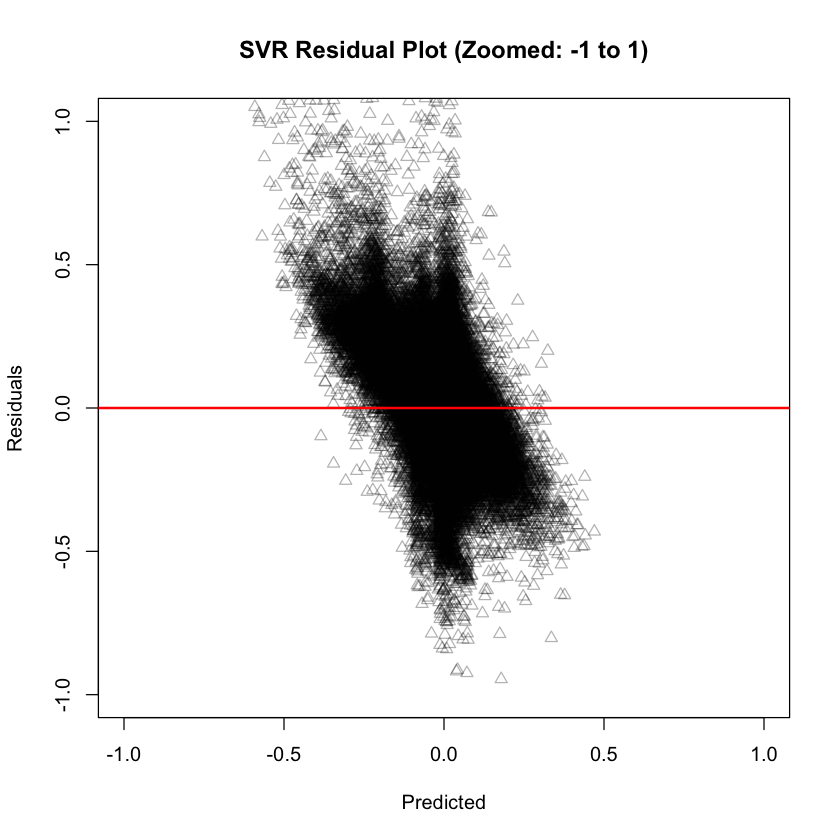

In [12]:
residuals <- predictions_df$actual - predictions_df$pred_svr

plot(predictions_df$pred_svr, residuals,
     xlab = "Predicted",
     ylab = "Residuals",
     main = "SVR Residual Plot (Zoomed: -1 to 1)",
     pch = 2,
     # Focus the scale
     xlim = c(-1, 1),
     ylim = c(-1, 1),
     col = rgb(0, 0, 0, 0.3)) # Adding transparency (0.3) helps see density

abline(h = 0, col = "red", lwd = 2)

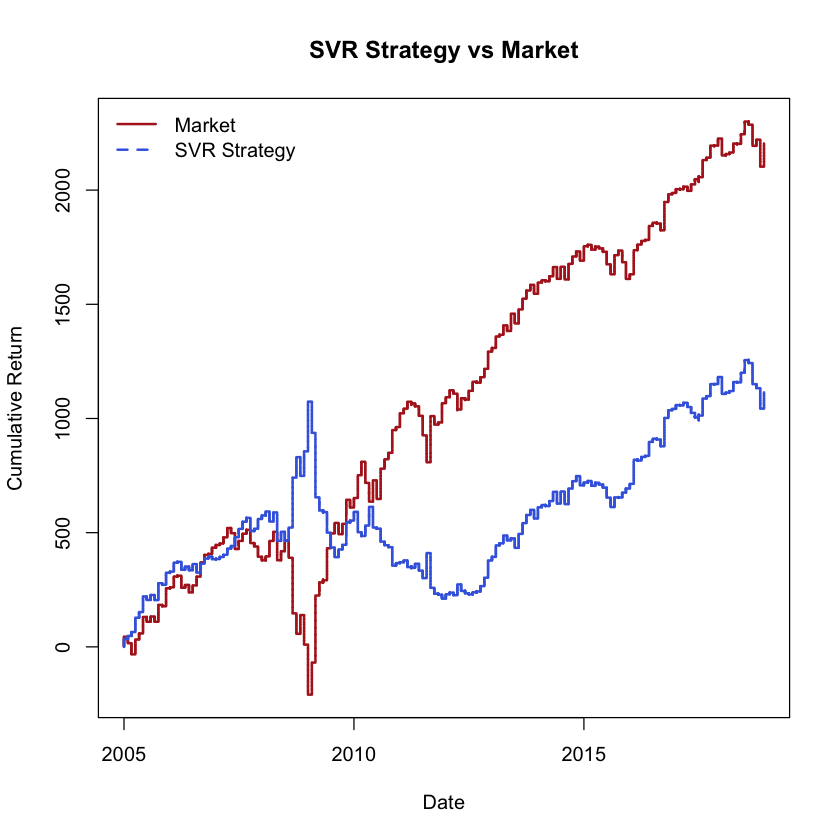

In [13]:
# Calculate returns
strategy_returns <- sign(predictions_df$pred_svr) * predictions_df$actual

cum_actual   <- cumsum(predictions_df$actual)
cum_strategy <- cumsum(strategy_returns)

# Plot the Market line (Solid Red)
plot(predictions_df$date, cum_actual,
     type = "l",
     col = "firebrick",          # Change Market color here
     lwd = 2,                    # Makes the line a bit thicker/cleaner
     xlab = "Date",
     ylab = "Cumulative Return",
     main = "SVR Strategy vs Market")

# Add the Strategy line (Dashed Blue)
lines(predictions_df$date, cum_strategy, 
      lty = 2, 
      col = "royalblue",         # Change Strategy color here
      lwd = 2)

# Update the legend to match colors and line types
legend("topleft", 
       legend = c("Market", "SVR Strategy"),
       lty = c(1, 2), 
       col = c("firebrick", "royalblue"), 
       lwd = 2,
       bty = "n")                # Removes the box around the legend for a cleaner look

---

For completeness, we include the results of running this regreesion with all features.

In [49]:
all_features <- data_ml %>%
  select(-stock_id, -date, -ends_with("_Usd")) %>% 
  colnames()


In [50]:
formula_ols <- as.formula(paste("R1M_Usd ~", paste(all_features, collapse = " + ")))
filtered_features <- select_top_features_lasso(calibration_data, all_features)
cat("LASSO-selected features (calibration 2000-2004):\n")
print(filtered_features)

LASSO-selected features (calibration 2000-2004):
 [1] "HML"             "Mkt_RF"          "SMB"             "RMW"            
 [5] "CMA"             "Hurst"           "Tev_Less_Mktcap" "Ev"             
 [9] "Cash_Div_Cf"     "Ebit_Noa"       


Run predictions for feature set beginning with all, then preprocessed with Lasso.

Apply rolling window approach again

In [14]:
# --- Rolling Window: All Features (LASSO-filtered) ---
results_list_all <- list()

for (i in 1:length(test_dates)) {
  current_date <- test_dates[i]

  train_data <- data_stock %>% filter(date < current_date) %>% tail(months_in_window)
  test_data  <- data_stock %>% filter(date == current_date)

  if(nrow(test_data) == 0 || nrow(train_data) < months_in_window) next

  # --- OLS (all features) ---
  fit_ols_all <- lm(formula_ols, data = train_data)
  pred_ols_all <- predict(fit_ols_all, test_data)

  # --- SVR (LASSO-filtered from all features) ---
  if (run_svr) {
    pred_svr_all <- run_svr_model(train_data, test_data, filtered_features)
  } else {
    pred_svr_all <- rep(NA, nrow(test_data))
  }

  results_list_all[[i]] <- data.frame(
    date         = current_date,
    stock_id     = test_data$stock_id,
    actual       = test_data$R1M_Usd,
    pred_ols_all = as.numeric(pred_ols_all),
    pred_svr_all = as.numeric(pred_svr_all)
  )
}

predictions_all_df <- bind_rows(results_list_all)

In [15]:
# --- Evaluate: All Features ---
eval_all <- na.omit(predictions_all_df)

cat("--- OLS (All Features) Performance ---\n")
compute_mse(eval_all$actual, eval_all$pred_ols_all)
compute_oos_r2(eval_all$actual, eval_all$pred_ols_all)

cat("\n--- SVR (All Features, LASSO-filtered) Performance ---\n")
compute_mse(eval_all$actual, eval_all$pred_svr_all)
compute_oos_r2(eval_all$actual, eval_all$pred_svr_all)

--- OLS (All Features) Performance ---
MSE (total): 0.290541 
Note: cross-term -2E[y<U+0177>] is most informative for portfolios
OOS R2: -8.3256 

--- SVR (All Features, LASSO-filtered) Performance ---
MSE (total): 0.03641 
Note: cross-term -2E[y<U+0177>] is most informative for portfolios
OOS R2: -0.1687 


In [16]:
# --- Hit Ratios & Sharpe: All Features ---
eval_all <- eval_all %>%
  mutate(
    ret_ols_all = sign(pred_ols_all) * actual,
    ret_svr_all = sign(pred_svr_all) * actual
  )

cat("OLS (All Features) Hit Ratio: ")
compute_hit_ratio(eval_all$actual, eval_all$pred_ols_all)

cat("SVR (All Features) Hit Ratio: ")
compute_hit_ratio(eval_all$actual, eval_all$pred_svr_all)

cat("\n--- OLS (All Features) Sharpe ---\n")
compute_sharpe(eval_all$ret_ols_all, returns_benchmark = eval_all$actual)

cat("\n--- SVR (All Features) Sharpe ---\n")
compute_sharpe(eval_all$ret_svr_all, returns_benchmark = eval_all$actual)

OLS (All Features) Hit Ratio: Hit ratio: 0.5178 
SVR (All Features) Hit Ratio: Hit ratio: 0.5294 

--- OLS (All Features) Sharpe ---
Sharpe ratio diagnostics:
  Avg monthly return   : 0.0069 
  Monthly volatility   : 0.1764 
  Sharpe (monthly)     : 0.0392 
  Sharpe (annualised)  : 0.136 
  Avg turnover         : 0 
  TC per unit turnover : 0 
  TC-adj Sharpe (ann)  : 0.136 
  Information ratio    : -0.0957 
  Tracking error (ann) : 0.5175 

--- SVR (All Features) Sharpe ---
Sharpe ratio diagnostics:
  Avg monthly return   : 0.0056 
  Monthly volatility   : 0.1764 
  Sharpe (monthly)     : 0.0315 
  Sharpe (annualised)  : 0.1092 
  Avg turnover         : 0 
  TC per unit turnover : 0 
  TC-adj Sharpe (ann)  : 0.1092 
  Information ratio    : -0.091 
  Tracking error (ann) : 0.7235 
